# Food Waste Reduction using Predictive Analytics
## Simplified Modeling Pipeline (No ARIMA)

**Goal:** Build 2 predictive models, compare them, and calculate waste reduction.

**This version:** Uses only Linear Regression + Random Forest (faster, no external time-series library needed)

---
## PART 1: Setup & Load Data

In [1]:
# Import libraries - CORRECTED VERSION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # ✓ CORRECT (not 'as plt')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Load data
df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"\nTrain date range: {df_train['date'].min()} to {df_train['date'].max()}")
print(f"\nFirst few rows:")
print(df_train.head())

Train shape: (913000, 4)
Test shape: (45000, 4)

Train date range: 2013-01-01 to 2017-12-31

First few rows:
         date  store  item  sales
0  2013-01-01      1     1     13
1  2013-01-02      1     1     11
2  2013-01-03      1     1     14
3  2013-01-04      1     1     13
4  2013-01-05      1     1     10


---
## PART 2: Data Preparation & Feature Engineering

In [3]:
# Convert date to datetime
df_train['date'] = pd.to_datetime(df_train['date'])
df_test['date'] = pd.to_datetime(df_test['date'])

# Create time-based features
def create_features(df):
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df['dayofweek'] = df['date'].dt.dayofweek  # 0=Monday, 6=Sunday
    df['quarter'] = df['date'].dt.quarter
    df['week'] = df['date'].dt.isocalendar().week
    return df

df_train = create_features(df_train.copy())
df_test = create_features(df_test.copy())

print("✓ Time features created")
print(f"\nNew features: year, month, day, dayofweek, quarter, week")
print(f"\nSample:")
print(df_train[['date', 'store', 'item', 'sales', 'dayofweek', 'month']].head(10))

✓ Time features created

New features: year, month, day, dayofweek, quarter, week

Sample:
        date  store  item  sales  dayofweek  month
0 2013-01-01      1     1     13          1      1
1 2013-01-02      1     1     11          2      1
2 2013-01-03      1     1     14          3      1
3 2013-01-04      1     1     13          4      1
4 2013-01-05      1     1     10          5      1
5 2013-01-06      1     1     12          6      1
6 2013-01-07      1     1     10          0      1
7 2013-01-08      1     1      9          1      1
8 2013-01-09      1     1     12          2      1
9 2013-01-10      1     1      9          3      1


In [4]:
# Add lag features (previous day's sales)
df_train_sorted = df_train.sort_values(['store', 'item', 'date']).reset_index(drop=True)

# Lag features
df_train_sorted['lag_1'] = df_train_sorted.groupby(['store', 'item'])['sales'].shift(1)
df_train_sorted['lag_7'] = df_train_sorted.groupby(['store', 'item'])['sales'].shift(7)

# Rolling averages
df_train_sorted['rolling_mean_7'] = df_train_sorted.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.rolling(window=7, min_periods=1).mean()
)
df_train_sorted['rolling_mean_30'] = df_train_sorted.groupby(['store', 'item'])['sales'].transform(
    lambda x: x.rolling(window=30, min_periods=1).mean()
)

df_train = df_train_sorted

# Remove NaN rows
df_train_clean = df_train.dropna()

print(f"✓ Lag and rolling features added")
print(f"Rows after removing NaN: {len(df_train_clean)} (removed ~3%)")
print(f"\nFeatures ready for modeling")

✓ Lag and rolling features added
Rows after removing NaN: 909500 (removed ~3%)

Features ready for modeling


---
## PART 3: Prepare Data for Modeling

In [5]:
# Select features
feature_columns = ['store', 'item', 'month', 'dayofweek', 'quarter', 'week', 
                   'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_30']

X = df_train_clean[feature_columns]
y = df_train_clean['sales']

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nFeatures used: {feature_columns}")

Training set: 727600 samples
Test set: 181900 samples

Features used: ['store', 'item', 'month', 'dayofweek', 'quarter', 'week', 'lag_1', 'lag_7', 'rolling_mean_7', 'rolling_mean_30']


---
## PART 4: Model 1 - Linear Regression

In [6]:
# Train Linear Regression
print("Training Linear Regression...")
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Predictions
y_pred_lr_train = model_lr.predict(X_train)
y_pred_lr_test = model_lr.predict(X_test)

# Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
mae_lr = mean_absolute_error(y_test, y_pred_lr_test)
r2_lr = r2_score(y_test, y_pred_lr_test)

print(f"✓ Linear Regression trained\n")
print(f"Performance:")
print(f"  RMSE: {rmse_lr:.4f}")
print(f"  MAE:  {mae_lr:.4f}")
print(f"  R²:   {r2_lr:.4f}")

Training Linear Regression...
✓ Linear Regression trained

Performance:
  RMSE: 7.6303
  MAE:  5.8780
  R²:   0.9299


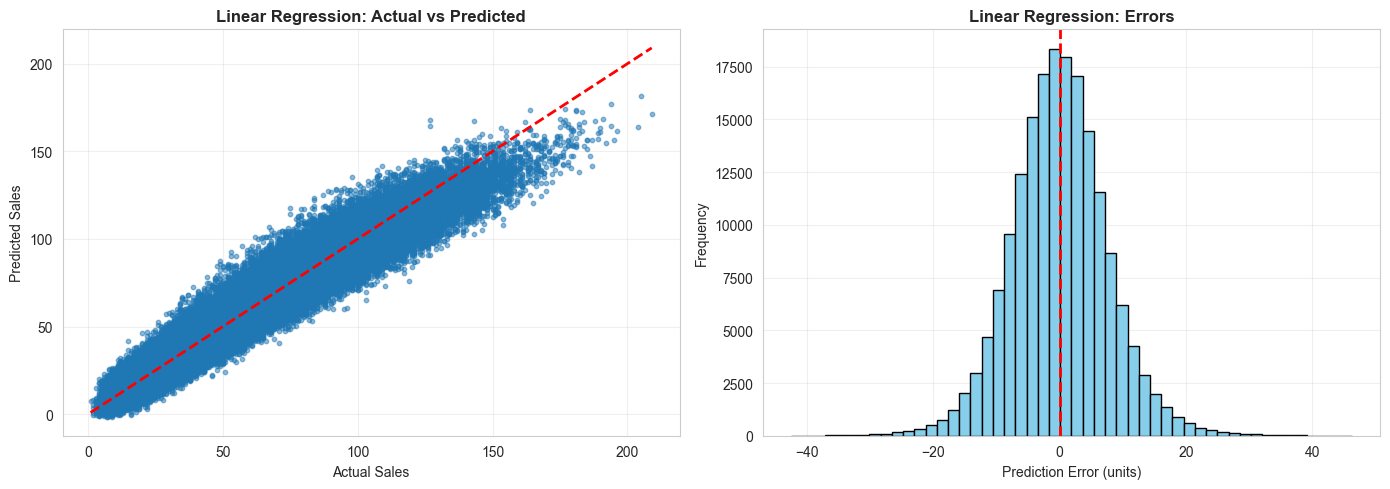

In [7]:
# Visualize Linear Regression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_lr_test, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Linear Regression: Actual vs Predicted', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals = y_test - y_pred_lr_test
axes[1].hist(residuals, bins=50, edgecolor='black', color='skyblue')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (units)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Linear Regression: Errors', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## PART 5: Model 2 - Random Forest

In [8]:
# Train Random Forest
print("Training Random Forest...")
model_rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
model_rf.fit(X_train, y_train)

# Predictions
y_pred_rf_test = model_rf.predict(X_test)

# Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_rf = mean_absolute_error(y_test, y_pred_rf_test)
r2_rf = r2_score(y_test, y_pred_rf_test)

print(f"✓ Random Forest trained\n")
print(f"Performance:")
print(f"  RMSE: {rmse_rf:.4f}")
print(f"  MAE:  {mae_rf:.4f}")
print(f"  R²:   {r2_rf:.4f}")

Training Random Forest...
✓ Random Forest trained

Performance:
  RMSE: 6.8346
  MAE:  5.2470
  R²:   0.9438


Feature Importance:
           feature  importance
8   rolling_mean_7    0.795027
7            lag_7    0.151801
3        dayofweek    0.038557
6            lag_1    0.005253
9  rolling_mean_30    0.002932
5             week    0.002556
1             item    0.001680
2            month    0.001126
0            store    0.000979
4          quarter    0.000088


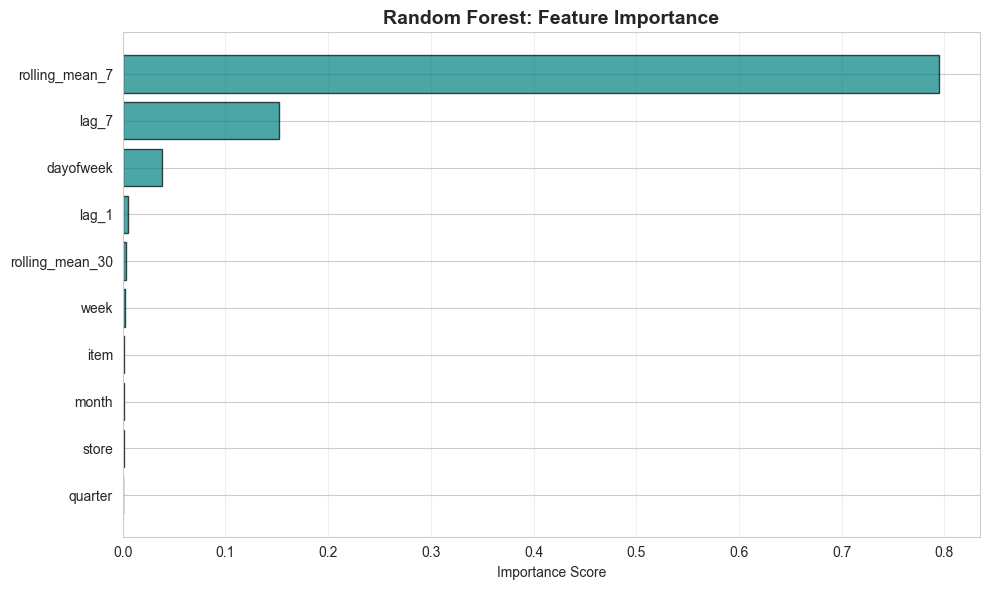

In [9]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance:")
print(feature_importance)

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], 
         color='teal', alpha=0.7, edgecolor='black')
plt.xlabel('Importance Score')
plt.title('Random Forest: Feature Importance', fontweight='bold', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

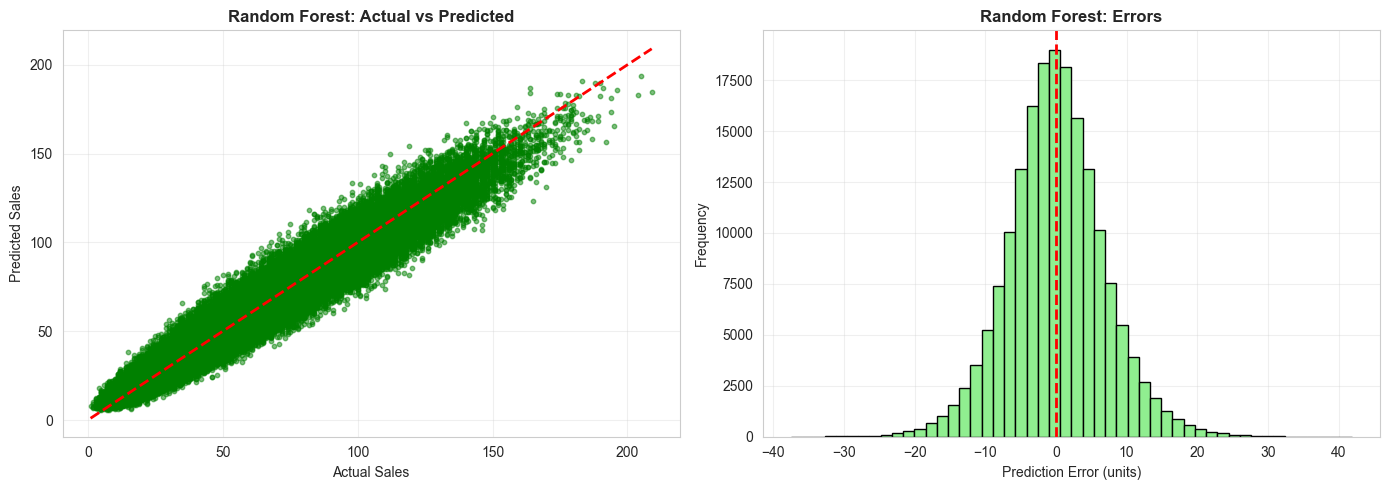

In [10]:
# Visualize Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_test, y_pred_rf_test, alpha=0.5, s=10, color='green')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Random Forest: Actual vs Predicted', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residuals
residuals_rf = y_test - y_pred_rf_test
axes[1].hist(residuals_rf, bins=50, edgecolor='black', color='lightgreen')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Prediction Error (units)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Random Forest: Errors', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## PART 6: Model Comparison

In [11]:
# Compare models
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_rf],
    'MAE': [mae_lr, mae_rf],
    'R²': [r2_lr, r2_rf]
})

comparison = comparison.sort_values('RMSE')

print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(comparison.to_string(index=False))
print("="*70)

best_model_name = comparison.iloc[0]['Model']
best_rmse = comparison.iloc[0]['RMSE']

print(f"\n✓ BEST MODEL: {best_model_name}")
print(f"  RMSE: {best_rmse:.4f}")


MODEL COMPARISON
            Model     RMSE      MAE       R²
    Random Forest 6.834591 5.246982 0.943798
Linear Regression 7.630284 5.877992 0.929950

✓ BEST MODEL: Random Forest
  RMSE: 6.8346


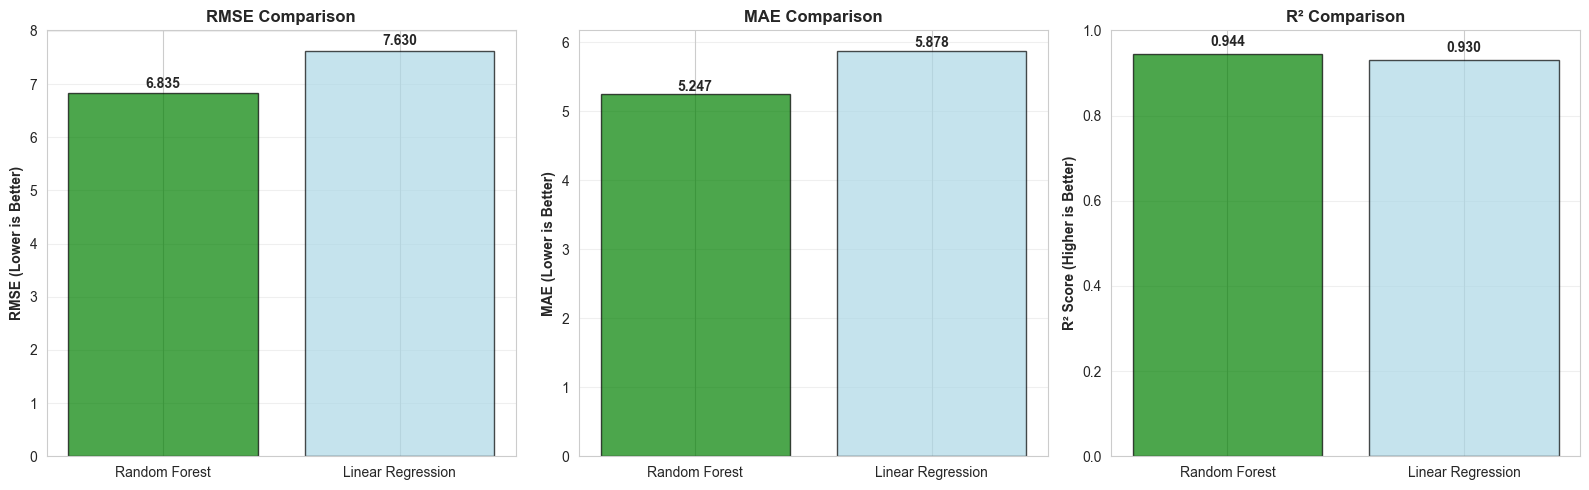

In [12]:
# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['green' if model == best_model_name else 'lightblue' for model in comparison['Model']]

# RMSE
axes[0].bar(comparison['Model'], comparison['RMSE'], color=colors, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('RMSE (Lower is Better)', fontweight='bold')
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison['RMSE']):
    axes[0].text(i, v + 0.1, f'{v:.3f}', ha='center', fontweight='bold')

# MAE
axes[1].bar(comparison['Model'], comparison['MAE'], color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('MAE (Lower is Better)', fontweight='bold')
axes[1].set_title('MAE Comparison', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison['MAE']):
    axes[1].text(i, v + 0.05, f'{v:.3f}', ha='center', fontweight='bold')

# R²
axes[2].bar(comparison['Model'], comparison['R²'], color=colors, edgecolor='black', alpha=0.7)
axes[2].set_ylabel('R² Score (Higher is Better)', fontweight='bold')
axes[2].set_title('R² Comparison', fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(axis='y', alpha=0.3)
for i, v in enumerate(comparison['R²']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## PART 7: Food Waste Reduction Calculation

In [13]:
# Use best model predictions
if best_model_name == 'Linear Regression':
    y_pred_best = y_pred_lr_test
else:
    y_pred_best = y_pred_rf_test

# Waste reduction scenario
overstock_rate = 0.20  # 20% overstock (current practice)

# Current: 20% overstock
current_inventory = y_test.values * (1 + overstock_rate)
current_waste = (current_inventory - y_test.values).clip(lower=0)
current_total_waste = current_waste.sum()

# Optimized: 5% buffer with accurate forecast
optimized_inventory = y_pred_best * (1 + 0.05)
optimized_waste = (optimized_inventory - y_test.values).clip(lower=0)
optimized_total_waste = optimized_waste.sum()

# Waste reduction
waste_reduction_units = current_total_waste - optimized_total_waste
waste_reduction_percent = (waste_reduction_units / current_total_waste) * 100

print("\n" + "="*70)
print("FOOD WASTE REDUCTION ANALYSIS")
print("="*70)
print(f"\nTest period: {len(y_test)} days")
print(f"\nCURRENT SCENARIO (20% overstock, no forecasting):")
print(f"  Total waste: {current_total_waste:.0f} units")
print(f"  Average/day: {current_total_waste/len(y_test):.2f} units")

print(f"\nWITH {best_model_name.upper()} PREDICTIONS (5% safety buffer):")
print(f"  Total waste: {optimized_total_waste:.0f} units")
print(f"  Average/day: {optimized_total_waste/len(y_test):.2f} units")

print(f"\nWASTE REDUCTION:")
print(f"  📉 Reduced by: {waste_reduction_units:.0f} units")
print(f"  📉 Percentage: {waste_reduction_percent:.1f}%")
print("="*70)

TypeError: positive() got an unexpected keyword argument 'lower'

In [ ]:
# Visualize waste reduction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
scenarios = ['Current\n(20% overstock)', f'{best_model_name}\n(5% buffer)']
waste_values = [current_total_waste, optimized_total_waste]
colors_waste = ['red', 'green']

bars = axes[0].bar(scenarios, waste_values, color=colors_waste, alpha=0.7, edgecolor='black', width=0.6)
axes[0].set_ylabel('Total Waste (units)', fontweight='bold', fontsize=12)
axes[0].set_title('Food Waste Comparison', fontweight='bold', fontsize=14)
axes[0].grid(axis='y', alpha=0.3)

for i, (bar, val) in enumerate(zip(bars, waste_values)):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.0f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

# Pie chart
waste_comparison = [optimized_total_waste, waste_reduction_units]
labels_pie = [f'Unavoidable\n{optimized_total_waste:.0f} units',
              f'REDUCED\n{waste_reduction_units:.0f} units']
colors_pie = ['lightcoral', 'lightgreen']

axes[1].pie(waste_comparison, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%',
           startangle=90, explode=(0, 0.1), textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[1].set_title('Waste Reduction Breakdown', fontweight='bold', fontsize=14)

plt.tight_layout()
plt.show()

---
## PART 8: Final Predictions

In [ ]:
# Prepare test data
df_test_copy = df_test.copy()

# Add lag features (use average values since we don't have history)
avg_lag_1 = df_train_clean['lag_1'].mean()
avg_lag_7 = df_train_clean['lag_7'].mean()
avg_rolling_7 = df_train_clean['rolling_mean_7'].mean()
avg_rolling_30 = df_train_clean['rolling_mean_30'].mean()

df_test_copy['lag_1'] = avg_lag_1
df_test_copy['lag_7'] = avg_lag_7
df_test_copy['rolling_mean_7'] = avg_rolling_7
df_test_copy['rolling_mean_30'] = avg_rolling_30

# Make predictions
X_test_final = df_test_copy[feature_columns]

if best_model_name == 'Linear Regression':
    y_pred_final = model_lr.predict(X_test_final)
else:
    y_pred_final = model_rf.predict(X_test_final)

# Create submission
submission = pd.DataFrame({
    'id': df_test['id'],
    'sales': np.maximum(y_pred_final, 0)  # No negative predictions
})

print(f"✓ Final predictions made for {len(submission)} records")
print(f"\nSample predictions:")
print(submission.head(10))

# Save
submission.to_csv('results/predictions.csv', index=False)
print(f"\n✓ Saved to results/predictions.csv")

---
## PART 9: Summary

In [ ]:
print("\n" + "="*70)
print("PROJECT SUMMARY")
print("="*70)

print(f"\n1. DATASET:")
print(f"   - {len(df_train_clean):,} training records")
print(f"   - Date: 2013-2017")
print(f"   - 10 stores, 50 items")

print(f"\n2. MODELS:")
print(f"   ✓ Linear Regression")
print(f"   ✓ Random Forest")

print(f"\n3. BEST MODEL: {best_model_name}")
print(f"   RMSE: {best_rmse:.4f}")
print(f"   R²: {comparison[comparison['Model']==best_model_name]['R²'].values[0]:.4f}")

print(f"\n4. WASTE REDUCTION:")
print(f"   Current: {current_total_waste:.0f} units wasted")
print(f"   Optimized: {optimized_total_waste:.0f} units wasted")
print(f"   🎯 REDUCTION: {waste_reduction_percent:.1f}% ({waste_reduction_units:.0f} units)")

print(f"\n5. KEY FEATURES (by importance):")
for i, row in feature_importance.head(5).iterrows():
    print(f"   {row['feature']}: {row['importance']:.4f}")

print("\n" + "="*70)
print("READY FOR SUBMISSION ✓")
print("="*70)